In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
banks = pd.read_csv('../Pipelines/data/masi_banques.csv')

## Clean data

In [3]:
banks = banks['ticker']
banks = banks.tolist()
banks

['ATW', 'BCP', 'BOA', 'BCI', 'CDM', 'CIH', 'CFG']

In [4]:


data_dir = Path('../Data/stock_history')

def parse_volume(val):
    val = str(val).strip().replace('.', '').replace(',', '.')
    if val.endswith('K'):
        return float(val[:-1]) * 1_000
    if val.endswith('M'):
        return float(val[:-1]) * 1_000_000
    return pd.to_numeric(val, errors='coerce')

dfs = {}
for f in data_dir.glob('* - Données Historiques.csv'):
    ticker = f.name.split(' - ')[0]
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    for col in ['Dernier', 'Ouv.', 'Plus Haut', 'Plus Bas']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'Vol.' in df.columns:
        df['Vol.'] = df['Vol.'].apply(parse_volume)

    if 'Variation %' in df.columns:
        df['Variation %'] = (df['Variation %'].astype(str)
                             .str.replace('%', '', regex=False)
                             .str.replace(',', '.', regex=False))
        df['Variation %'] = pd.to_numeric(df['Variation %'], errors='coerce')

    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df = df.sort_values('Date').reset_index(drop=True)
    dfs[ticker] = df
	# Re-save CSVs without quotes
    output_dir = Path('../Data/stock_history_clean')
    output_dir.mkdir(parents=True, exist_ok=True)

    for f in data_dir.glob('* - Données Historiques.csv'):
        ticker = f.name.split(' - ')[0]
        if ticker in dfs:
        	dfs[ticker].to_csv(output_dir / f.name, index=False)


C:\Users\anasw\AppData\Local\Temp\ipykernel_31012\1841369205.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


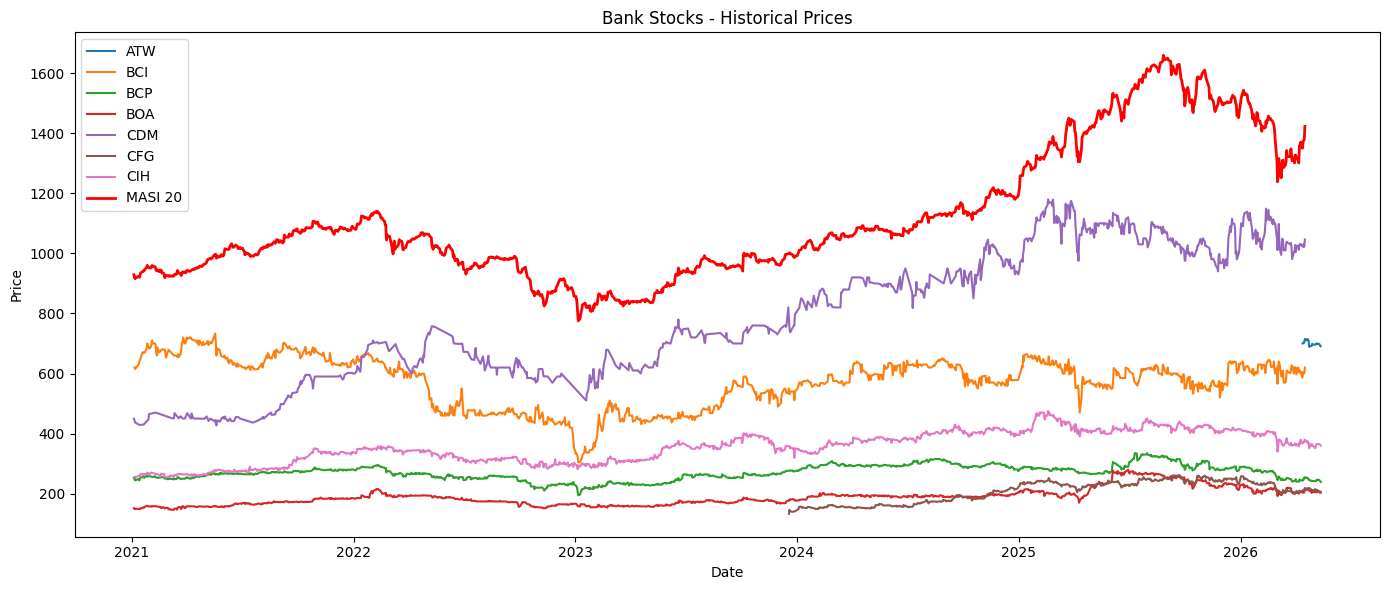

In [5]:

fig, ax = plt.subplots(figsize=(14, 6))
date_col = 'Date'
price_col = 'Dernier'


filtered = {ticker: df for ticker, df in dfs.items() if ticker in banks}


for ticker, df in filtered.items() :
    ax.plot(df[date_col], df[price_col], label=ticker)
    
ax.plot(dfs['Masi 20'][date_col], dfs['Masi 20'][price_col], label="MASI 20", linewidth=2, color = 'red')

ax.set_title('Bank Stocks - Historical Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()